# Task 1: Laying the Foundation for Brent Oil Price Analysis

## Purpose

This notebook develops the analytical foundation for studying structural
changes in Brent crude oil prices. It covers data quality assessment, trend
analysis, stationarity testing, return analysis, volatility analysis, event
research, modeling plans, assumptions, and limitations.

The analysis is intended to support Birhan Energies in communicating
data-driven insights to investors, energy companies, and policymakers.

In [15]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "BrentOilPrices.csv"
EVENTS_PATH = PROJECT_ROOT / "data" / "events" / "key_oil_market_events.csv"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"

FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data exists: {DATA_PATH.exists()}")
print(f"Events data exists: {EVENTS_PATH.exists()}")

Project root: c:\Users\gebre\OneDrive\Documents\Programming\KIAM 10 academy\Week 10\brent-oil-change-point-analysis
Data exists: True
Events data exists: True


In [16]:
prices = pd.read_csv(DATA_PATH)
events = pd.read_csv(EVENTS_PATH)

print("Brent oil price data:")
display(prices.head())

print("\nOil-market event data:")
display(events.head())

Brent oil price data:


,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63



Oil-market event data:


,event_date,event_name,event_category,event_description,expected_market_channel,source_organization
0,1990-08-02,Iraq invades Kuwait,Geopolitical conflict,Iraq invaded Kuwait and disrupted oil producti...,Negative supply shock and upward price pressure,U.S. Energy Information Administration
1,1991-01-17,Operation Desert Storm begins,Geopolitical conflict,Coalition military operations began during the...,Supply uncertainty and elevated geopolitical risk,U.S. Energy Information Administration
2,1997-07-02,Asian financial crisis begins,Economic shock,Thailand abandoned its fixed exchange rate and...,Reduced regional economic activity and oil demand,International Monetary Fund
3,2001-09-11,September 11 attacks,Geopolitical shock,Terrorist attacks in the United States created...,Lower aviation demand and increased uncertainty,U.S. Energy Information Administration
4,2003-03-20,Iraq War begins,Geopolitical conflict,Military operations began in Iraq,Supply disruption fears and geopolitical risk,U.S. Energy Information Administration


In [17]:
print("Price dataset shape:", prices.shape)
print("\nColumn data types:")
print(prices.dtypes)

print("\nMissing values:")
print(prices.isna().sum())

print("\nDuplicate rows:", prices.duplicated().sum())

Price dataset shape: (9011, 2)

Column data types:
Date         str
Price    float64
dtype: object

Missing values:
Date     0
Price    0
dtype: int64

Duplicate rows: 0


In [18]:
prices["Date"] = pd.to_datetime(
    prices["Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce",
)

prices["Price"] = pd.to_numeric(
    prices["Price"],
    errors="coerce",
)

prices = (
    prices
    .dropna(subset=["Date", "Price"])
    .drop_duplicates(subset=["Date"])
    .sort_values("Date")
    .reset_index(drop=True)
)

events["event_date"] = pd.to_datetime(
    events["event_date"],
    errors="coerce",
)

print("Cleaned shape:", prices.shape)
print("Start date:", prices["Date"].min())
print("End date:", prices["Date"].max())
print("Missing values after cleaning:")
print(prices.isna().sum())

Cleaned shape: (9011, 2)
Start date: 1987-05-20 00:00:00
End date: 2022-11-14 00:00:00
Missing values after cleaning:
Date     0
Price    0
dtype: int64


In [19]:
display(prices["Price"].describe().to_frame().T)

print(f"Average Brent price: ${prices['Price'].mean():.2f}")
print(f"Median Brent price: ${prices['Price'].median():.2f}")
print(f"Minimum Brent price: ${prices['Price'].min():.2f}")
print(f"Maximum Brent price: ${prices['Price'].max():.2f}")

,count,mean,std,min,25%,50%,75%,max
Price,9011.0,48.420782,32.86011,9.1,19.05,38.57,70.09,143.95


Average Brent price: $48.42
Median Brent price: $38.57
Minimum Brent price: $9.10
Maximum Brent price: $143.95


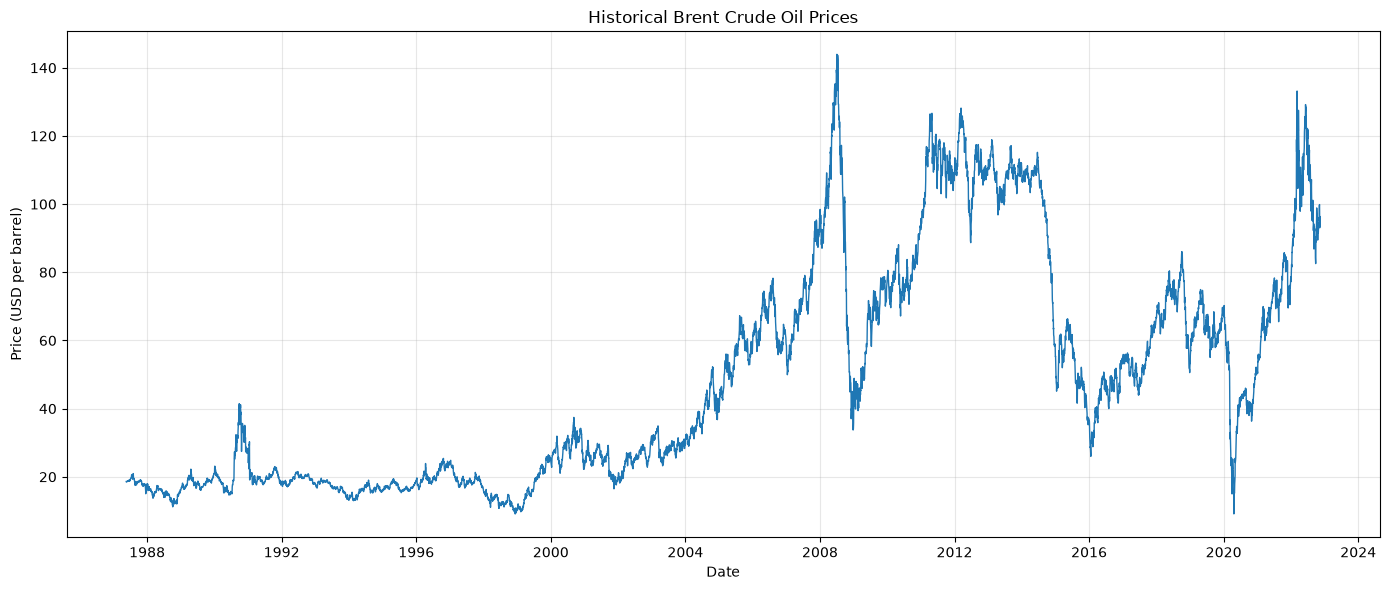

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    prices["Date"],
    prices["Price"],
    linewidth=1,
)

ax.set_title("Historical Brent Crude Oil Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD per barrel)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "brent_price_history.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Trend Interpretation

The Brent price series displays substantial long-term variation rather than a
constant average. The chart contains periods of sustained price growth, sharp
declines, recoveries, and isolated shocks. This indicates that the raw price
series may be non-stationary and may contain structural breaks.

The visual pattern supports the use of change point analysis because a single
mean and variance are unlikely to describe the entire historical period.

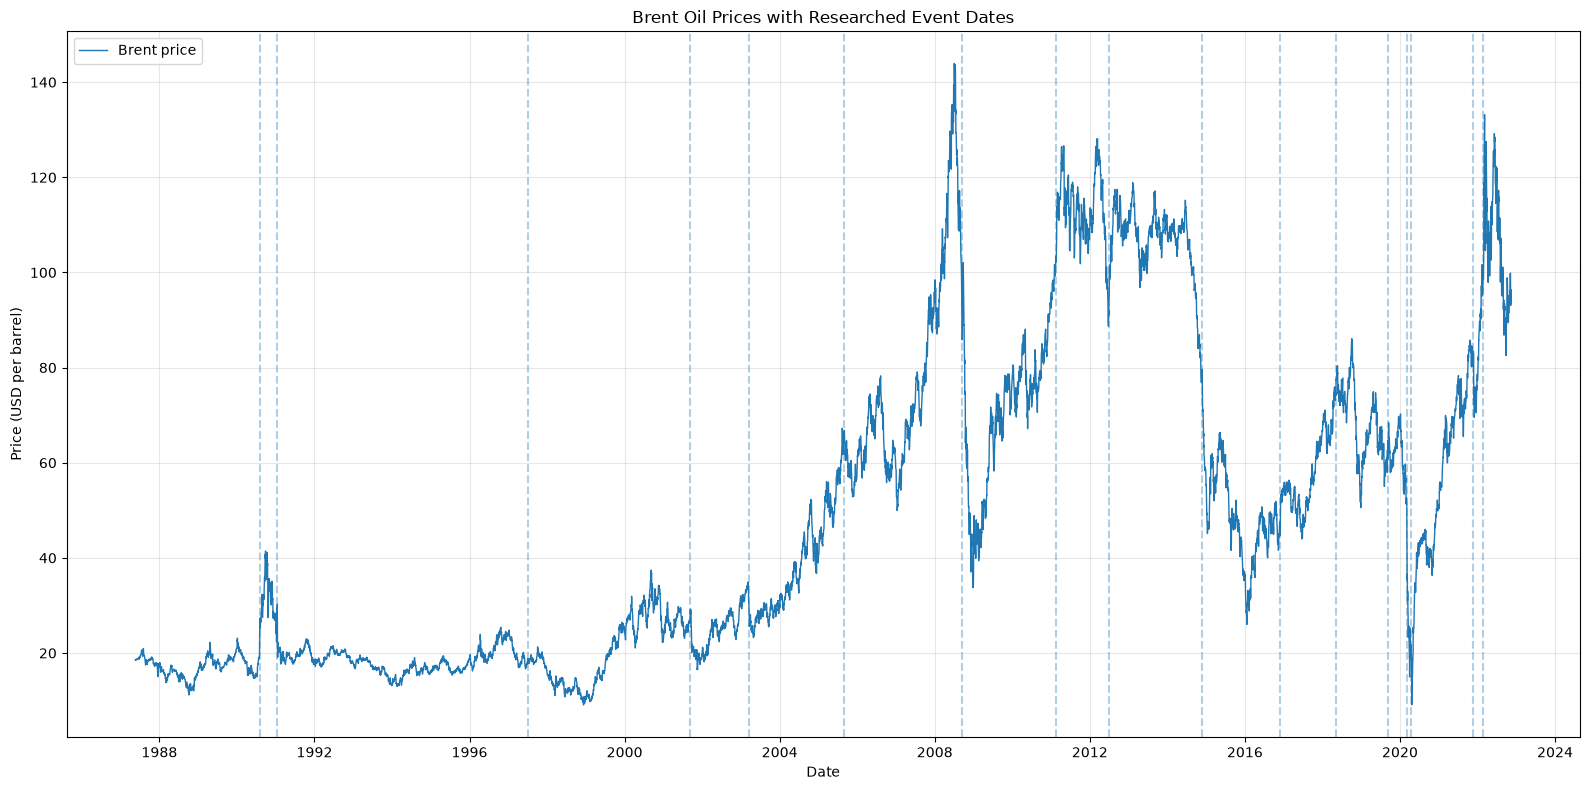

In [21]:
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(
    prices["Date"],
    prices["Price"],
    linewidth=1,
    label="Brent price",
)

for _, event in events.iterrows():
    if prices["Date"].min() <= event["event_date"] <= prices["Date"].max():
        ax.axvline(
            event["event_date"],
            linestyle="--",
            alpha=0.35,
        )

ax.set_title("Brent Oil Prices with Researched Event Dates")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD per barrel)")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "brent_prices_with_events.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Event Overlay Interpretation

The vertical lines show the timing of selected geopolitical, economic, health,
and OPEC events. Temporal proximity between an event and a price movement can
help generate a hypothesis, but it does not by itself prove that the event
caused the movement.

Some events may have been anticipated before their official dates, while
several events may occur within the same period. Oil prices may also react to
changes in supply, demand, inventories, exchange rates, interest rates, and
market expectations that are not contained in this event dataset.

In [22]:
prices["Log_Price"] = np.log(prices["Price"])
prices["Log_Return"] = prices["Log_Price"].diff()

display(prices[["Date", "Price", "Log_Return"]].head())

,Date,Price,Log_Return
0,1987-05-20,18.63,NaN
1,1987-05-21,18.45,-0.009709
2,1987-05-22,18.55,0.005405
3,1987-05-25,18.60,0.002692
4,1987-05-26,18.63,0.001612


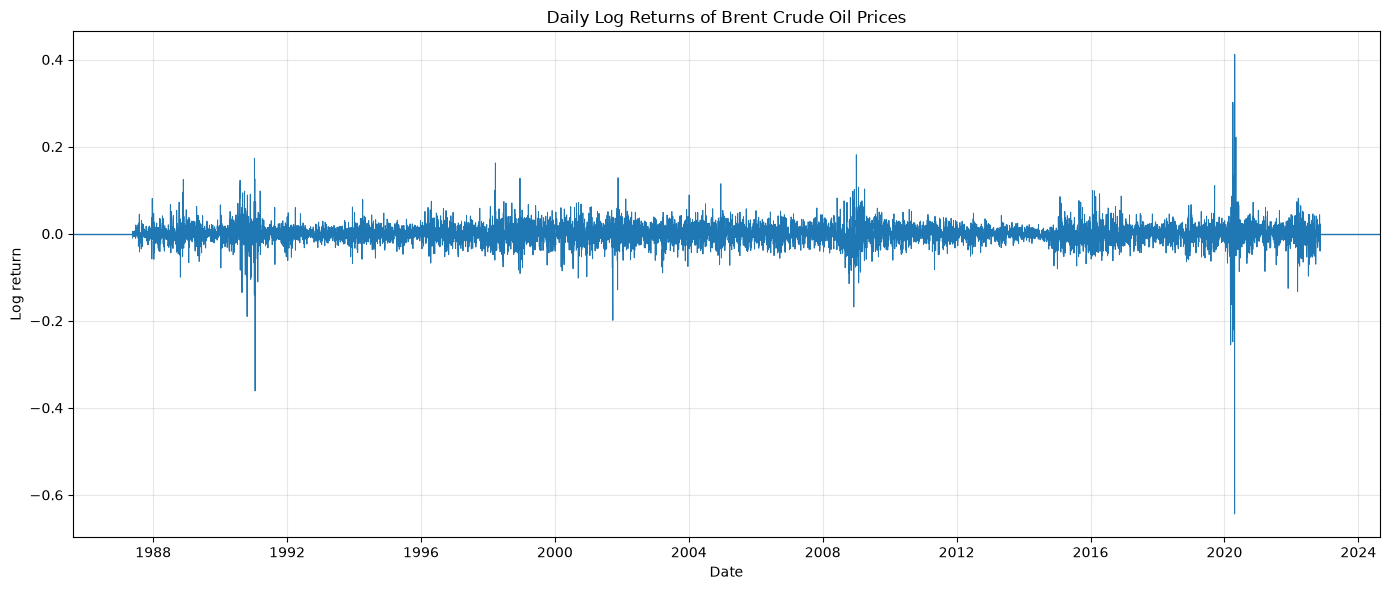

In [23]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    prices["Date"],
    prices["Log_Return"],
    linewidth=0.7,
)

ax.axhline(0, linewidth=1)
ax.set_title("Daily Log Returns of Brent Crude Oil Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Log return")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "brent_log_returns.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Return and Volatility Interpretation

Daily log returns fluctuate around a level closer to zero than the raw price
series. However, the magnitude of the fluctuations changes over time.
Periods with many large positive and negative returns indicate volatility
clustering.

This suggests that price changes are not equally volatile throughout the
dataset. Modeling the raw prices may help detect changes in average price
levels, while modeling log returns may be more appropriate when examining
changes in short-term market behaviour and volatility.

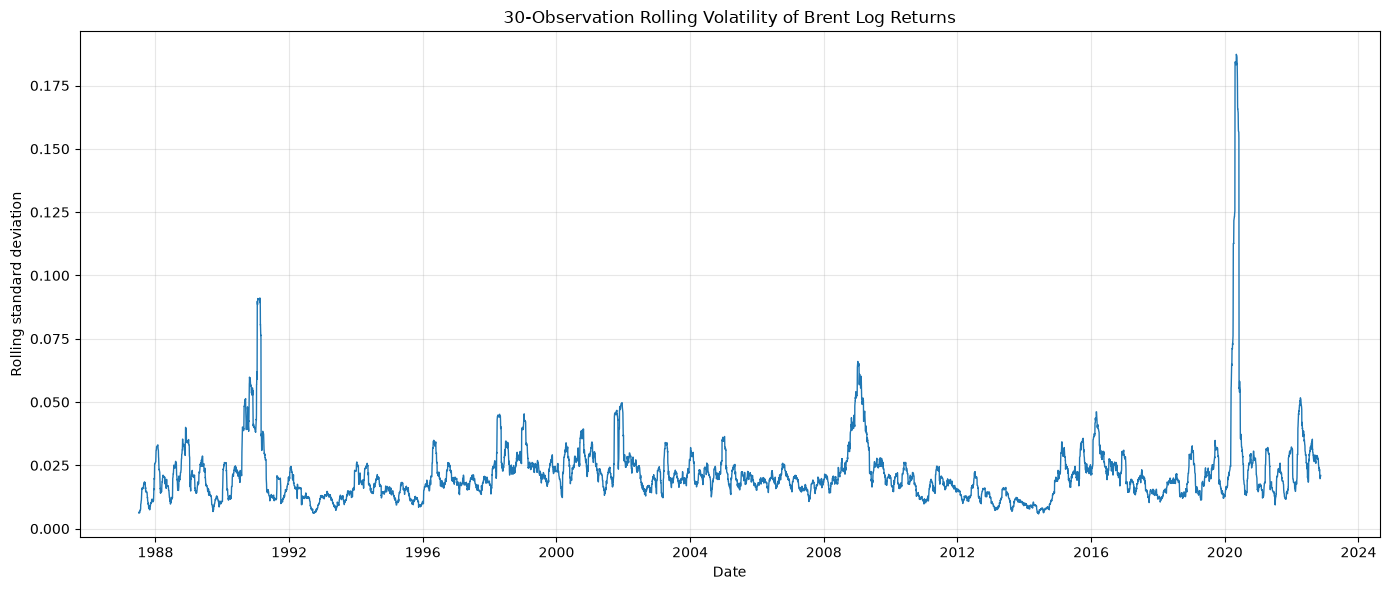

In [24]:
prices["Rolling_30D_Volatility"] = (
    prices["Log_Return"]
    .rolling(window=30)
    .std()
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    prices["Date"],
    prices["Rolling_30D_Volatility"],
    linewidth=1,
)

ax.set_title("30-Observation Rolling Volatility of Brent Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling standard deviation")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "brent_rolling_volatility.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [25]:
def run_adf_test(series: pd.Series, series_name: str) -> dict:
    """Run and display an Augmented Dickey-Fuller stationarity test."""

    clean_series = series.dropna()

    result = adfuller(
        clean_series,
        autolag="AIC",
    )

    output = {
        "Series": series_name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Observations": result[3],
        "1% Critical Value": result[4]["1%"],
        "5% Critical Value": result[4]["5%"],
        "10% Critical Value": result[4]["10%"],
    }

    return output


adf_results = pd.DataFrame(
    [
        run_adf_test(prices["Price"], "Raw price"),
        run_adf_test(prices["Log_Return"], "Log return"),
    ]
)

display(adf_results)

,Series,ADF Statistic,p-value,Observations,1% Critical Value,5% Critical Value,10% Critical Value
0,Raw price,-1.993856,2.892735e-01,8981,-3.431078,-2.861862,-2.566941
1,Log return,-16.427113,2.498580e-29,8981,-3.431078,-2.861862,-2.566941


In [26]:
for _, row in adf_results.iterrows():
    if row["p-value"] < 0.05:
        conclusion = "Reject the null hypothesis; the series appears stationary."
    else:
        conclusion = (
            "Fail to reject the null hypothesis; the series appears non-stationary."
        )

    print(f"{row['Series']}: p-value = {row['p-value']:.6f}")
    print(conclusion)
    print("-" * 70)

Raw price: p-value = 0.289274
Fail to reject the null hypothesis; the series appears non-stationary.
----------------------------------------------------------------------
Log return: p-value = 0.000000
Reject the null hypothesis; the series appears stationary.
----------------------------------------------------------------------


### Stationarity and Modeling Implications

The Augmented Dickey-Fuller test evaluates the null hypothesis that a series
contains a unit root. A p-value below 0.05 provides evidence against the unit
root hypothesis.

For the raw Brent price series, the ADF test produced a p-value of approximately
0.289. Because this is greater than 0.05, the null hypothesis cannot be rejected,
indicating that the raw price series is non-stationary.

For daily log returns, the p-value was effectively zero. The null hypothesis is
therefore rejected, indicating that log returns are stationary. Differencing the
log price removes much of the long-term trend observed in the price level.

These findings inform the Task 2 modeling choices:

- Raw or log prices can be used to detect structural changes in market price levels.
- Log returns are more appropriate for analyzing proportional daily movements.
- Changes in volatility may require a model that allows the variance to change.
- A simple Bayesian model can begin with one change in the mean before being
  extended to more complex specifications.

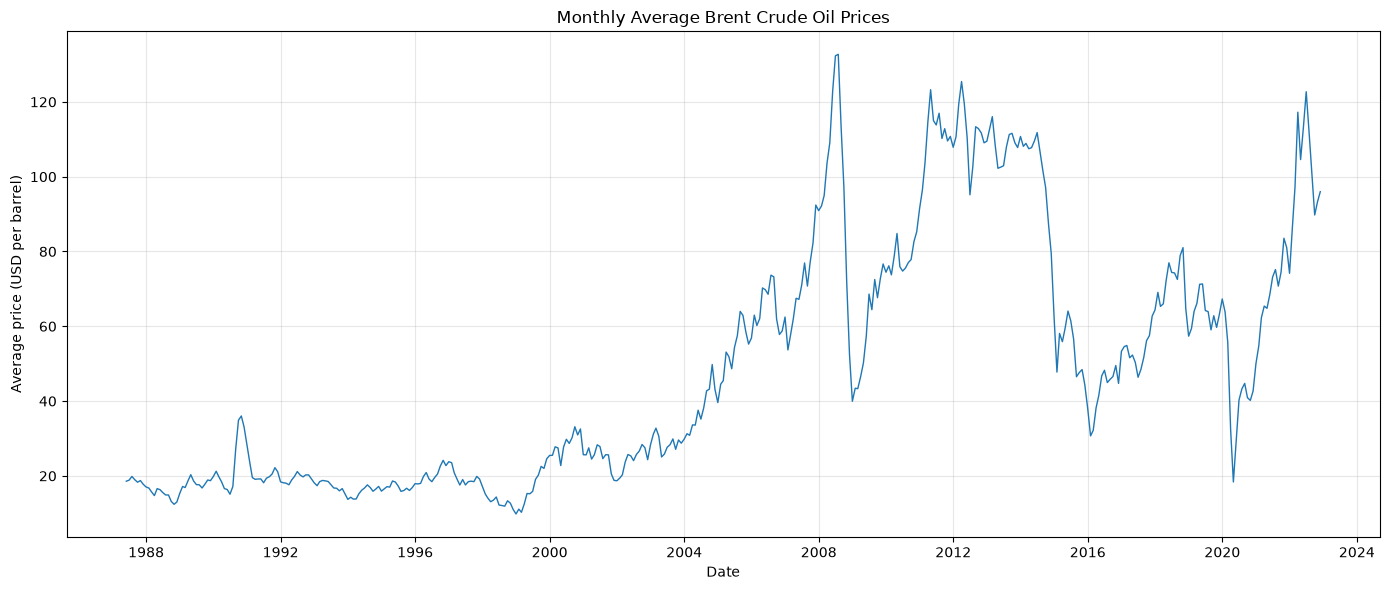

In [27]:
monthly_prices = (
    prices
    .set_index("Date")["Price"]
    .resample("ME")
    .mean()
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    monthly_prices.index,
    monthly_prices.values,
    linewidth=1,
)

ax.set_title("Monthly Average Brent Crude Oil Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Average price (USD per barrel)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_PATH / "monthly_average_brent_prices.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Planned Data Analysis Workflow

### 1. Define the Business Question

The analysis will investigate when the statistical behaviour of Brent oil
prices changed and whether the dates of those changes align with major
geopolitical, economic, health, or OPEC-related events.

### 2. Acquire and Validate Data

The supplied Brent price dataset will be loaded and checked for missing
values, invalid dates, duplicates, non-numeric prices, chronological order,
and coverage. A separate event dataset will contain researched event dates,
descriptions, categories, expected transmission channels, and source
organizations.

### 3. Prepare the Time Series

Dates will be converted to datetime format and prices will be ordered
chronologically. Daily log returns will be calculated as:

log(Price_t) - log(Price_(t-1))

Both price levels and log returns will be retained because they answer
different questions.

### 4. Conduct Exploratory Analysis

The analysis will examine:

- Historical price trends
- Descriptive statistics
- Large price increases and declines
- Stationarity using the Augmented Dickey-Fuller test
- Log-return behaviour
- Rolling volatility
- Visual proximity between events and price movements

### 5. Build Bayesian Change Point Models

A Bayesian change point model will estimate an unknown switch date, tau, and
separate parameters before and after the switch. Initial models will examine
changes in the mean price or mean log return. The model may later be extended
to examine changes in variance or more than one structural break.

### 6. Evaluate the Model

Posterior trace plots, effective sample sizes, posterior distributions and
r-hat statistics will be reviewed. Posterior predictive checks will be used
where appropriate to assess whether the model represents important features
of the observed data.

### 7. Compare Change Points with Events

Detected dates will be compared with the researched events. Events located
near high-probability change points will be treated as plausible explanatory
hypotheses rather than automatically being classified as causes.

### 8. Quantify and Communicate Impact

For important change points, the analysis will report the estimated parameter
before and after the break, the absolute difference, percentage difference,
uncertainty intervals, and relevant event context. Results will be
communicated through a report and an interactive dashboard.

## Purpose of Change Point Analysis

A change point is a time at which the statistical properties of a sequence
change. In the Brent oil context, this may represent a shift in the average
price, average return, volatility, trend, or another model parameter.

A Bayesian change point model treats the change date as an unknown parameter.
For a basic one-change model:

- tau represents the unknown change date.
- mu_before represents the mean before tau.
- mu_after represents the mean after tau.
- A switch function assigns the correct mean to each observation.
- A likelihood connects the selected mean to the observed series.

Bayesian inference produces a posterior distribution rather than only one
estimated date. This allows the analysis to communicate uncertainty about
where the structural break occurred and uncertainty about the parameter
values before and after it.

## Expected Outputs

The expected outputs of the change point analysis include:

1. A posterior distribution for the change point date.
2. A most probable change point date or date range.
3. Estimated mean or volatility parameters before and after the change.
4. Credible intervals describing parameter uncertainty.
5. Trace plots and convergence diagnostics.
6. A visualization of the historical series with the detected break.
7. Quantified changes in price behaviour.
8. Comparison between detected changes and researched events.

A narrow posterior distribution for the change point would indicate greater
certainty about its location. A broad or multimodal distribution would
indicate that several dates may plausibly explain the change.

## Assumptions

1. The supplied Brent prices are accurate and expressed consistently in
   nominal US dollars per barrel.
2. Each row represents the market price corresponding to its recorded date.
3. Missing weekends and market holidays reflect the structure of the source
   series rather than missing-data errors.
4. The researched event dates are reasonable approximations of when each
   event became publicly relevant.
5. A basic change point model assumes observations within each regime can be
   described by the selected probability distribution and parameters.
6. The first Bayesian model will assume one dominant structural break,
   although the full history may contain several breaks.
7. Log returns are used to reduce trend effects and permit comparison of
   proportional changes across different price levels.

## Limitations

1. Temporal correlation does not establish causal impact. An event occurring
   close to a detected change point is evidence of timing alignment, not proof
   that the event caused the change.
2. Oil prices are influenced simultaneously by supply, demand, inventories,
   expectations, exchange rates, interest rates, production capacity and
   financial-market conditions.
3. Markets may anticipate events before their official start dates, making
   the measured response appear earlier than the recorded event.
4. Several events may overlap, making their separate effects difficult to
   identify.
5. The event dataset is selective and may omit relevant local or gradual
   developments.
6. A one-change model can oversimplify a time series that contains multiple
   structural regimes.
7. A model focused only on a changing mean may fail to capture important
   changes in volatility.
8. Daily observations may contain autocorrelation and changing variance,
   which violate the assumptions of a simple independent Normal likelihood.
9. Prices are nominal and are not adjusted for inflation.
10. The assignment describes coverage to September 2022, while the supplied
    file continues to November 2022. The analysis uses the actual supplied
    records and documents this difference.
11. Results based on historical associations may not generalize to future oil
    market conditions.

## Initial Task 1 Findings

The supplied dataset contains 9,011 Brent oil price observations from
20 May 1987 to 14 November 2022, with no missing values or duplicate rows.
Prices range from $9.10 to $143.95 per barrel, with an average price of $48.42.

Historical and monthly price plots reveal substantial long-term changes,
including sustained growth periods, sharp declines, recoveries, and major
market shocks. The rolling-volatility analysis also shows that the variability
of returns changes considerably over time, with the most extreme volatility
appearing around 2020.

The Augmented Dickey-Fuller test returned a p-value of approximately 0.289 for
the raw price series, indicating that it is non-stationary. In contrast, the
daily log-return series produced a p-value effectively equal to zero and was
found to be stationary.

These results support the use of Bayesian change point analysis. Raw prices may
be used to identify structural changes in market price levels, while log returns
provide a more suitable representation for examining proportional changes and
volatility. Detected change points will later be compared with the researched
event dataset, while treating temporal alignment as evidence for a hypothesis
rather than proof of causality.